# Notebook 15: Feature Importance and Selection

Load data and run 5-fold LOYOCV with the same pipeline as Notebook 13.

Permutation importance shows which features matter most by shuffling each feature and checking how much the model performance drops.

Export per-fold permutation importance for each model. Visualise top features and rank stability across folds.

NOTEBOOK 14_v2: FEATURE IMPORTANCE AND SELECTION (UPDATED)
Results directory: C:\Users\Nikita Danvill\OneDrive - University of Otago\Documents\INFO501\Nikita_Danvill_8887029_JupyterNotebooks_INFO501\Results

THRESHOLDS (from NB13_v2 Balanced Accuracy optimization):
  Logistic Regression       0.50
  Random Forest             0.55
  Gradient Boosting         0.60
  SVM                       0.65
     Check: Notebook_13_v2_Results.xlsx 'threshold' column for per-year averages

STEP 1: Loading remediated features...
✓ Loaded 21 features
✓ Outcome: Pass=887, Fail=267
✓ Test years: [2014, 2015, 2016, 2017, 2018]

STEP 2: LOYOCV evaluation (5-fold, 2014-2018)...

  Test year: 2014

  Test year: 2015

  Test year: 2016

  Test year: 2017

  Test year: 2018

STEP 3: Generating summary...
✓ Saved: C:\Users\Nikita Danvill\OneDrive - University of Otago\Documents\INFO501\Nikita_Danvill_8887029_JupyterNotebooks_INFO501\Results\Notebook_14_v2_Feature_Importance_Updated.xlsx

SUMMARY TABLE (mean acr

,Model,Bal.Acc (mean),Bal.Acc (std),Recall(Fail),F1(Fail),AUC
0,Logistic Regression,0.722,0.046,0.665,0.551,0.807
1,Random Forest,0.724,0.024,0.750,0.552,0.807
2,Gradient Boosting,0.707,0.073,0.549,0.538,0.799
3,SVM,0.727,0.056,0.635,0.564,0.774



STEP 4: Generating visualizations...


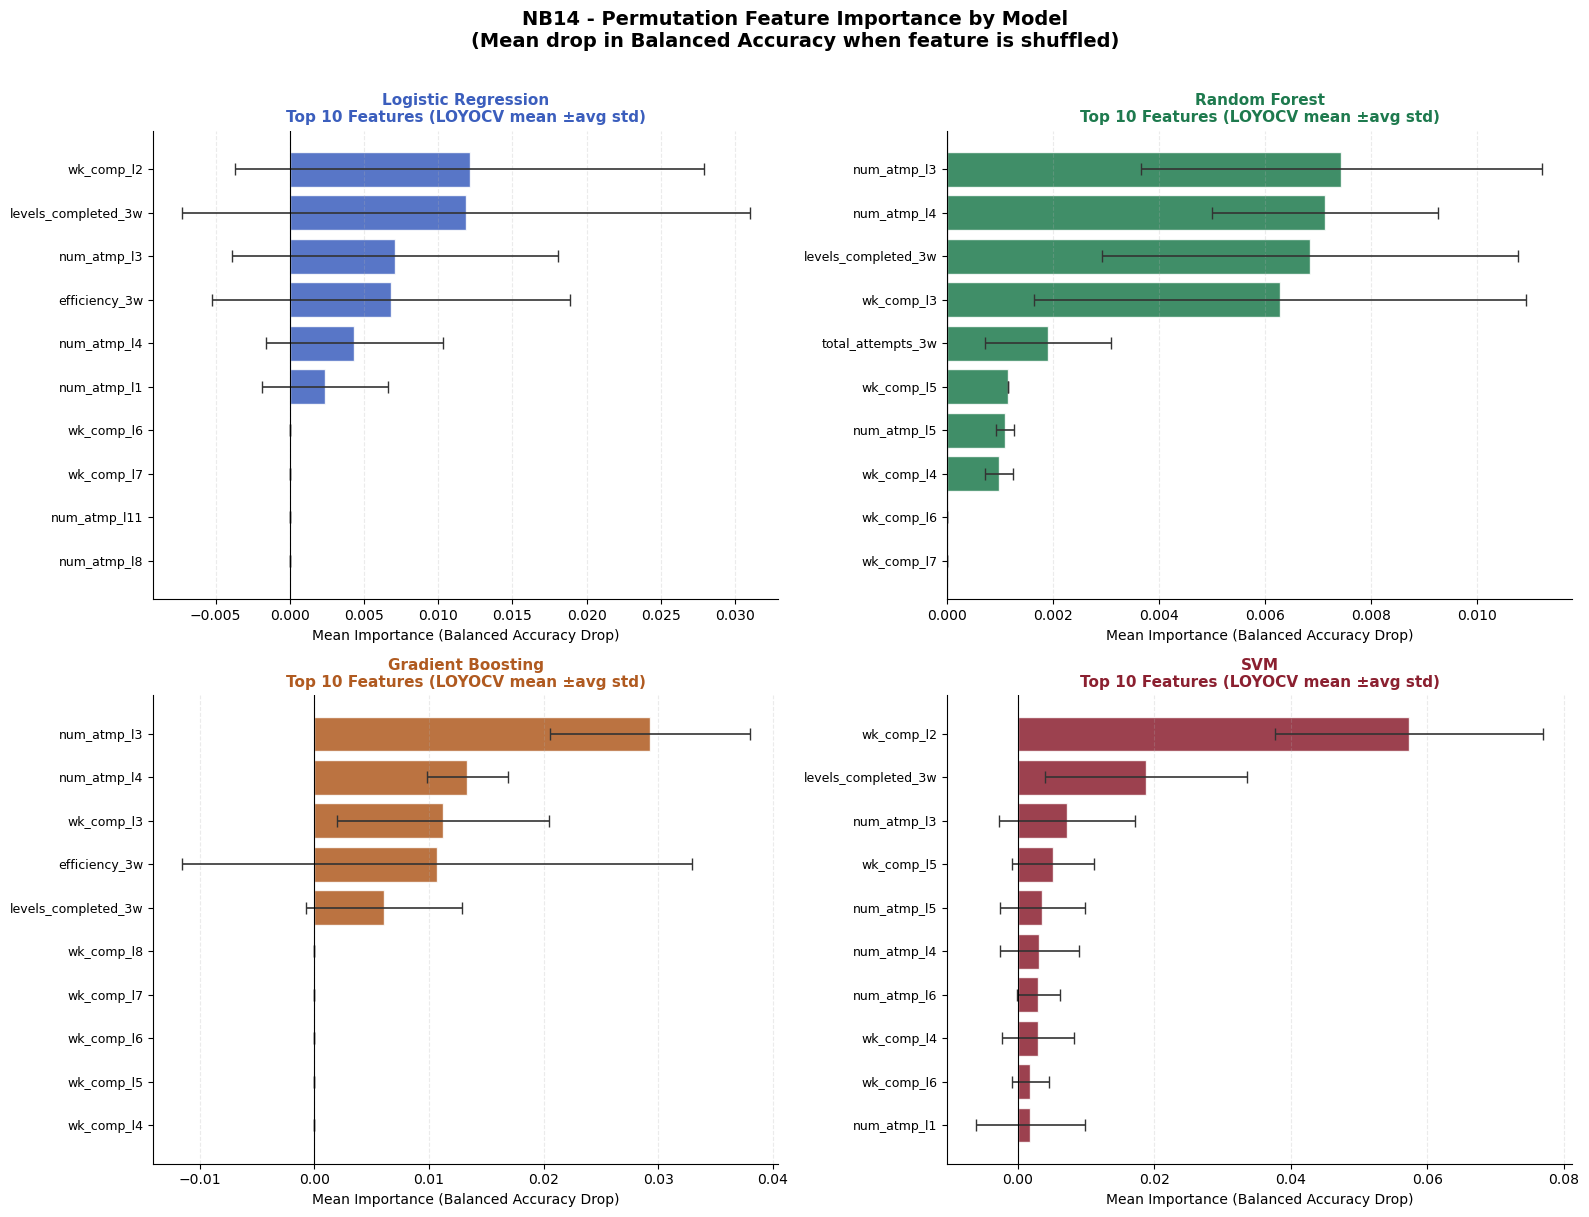

  ✓ Chart 1: Permutation importance saved


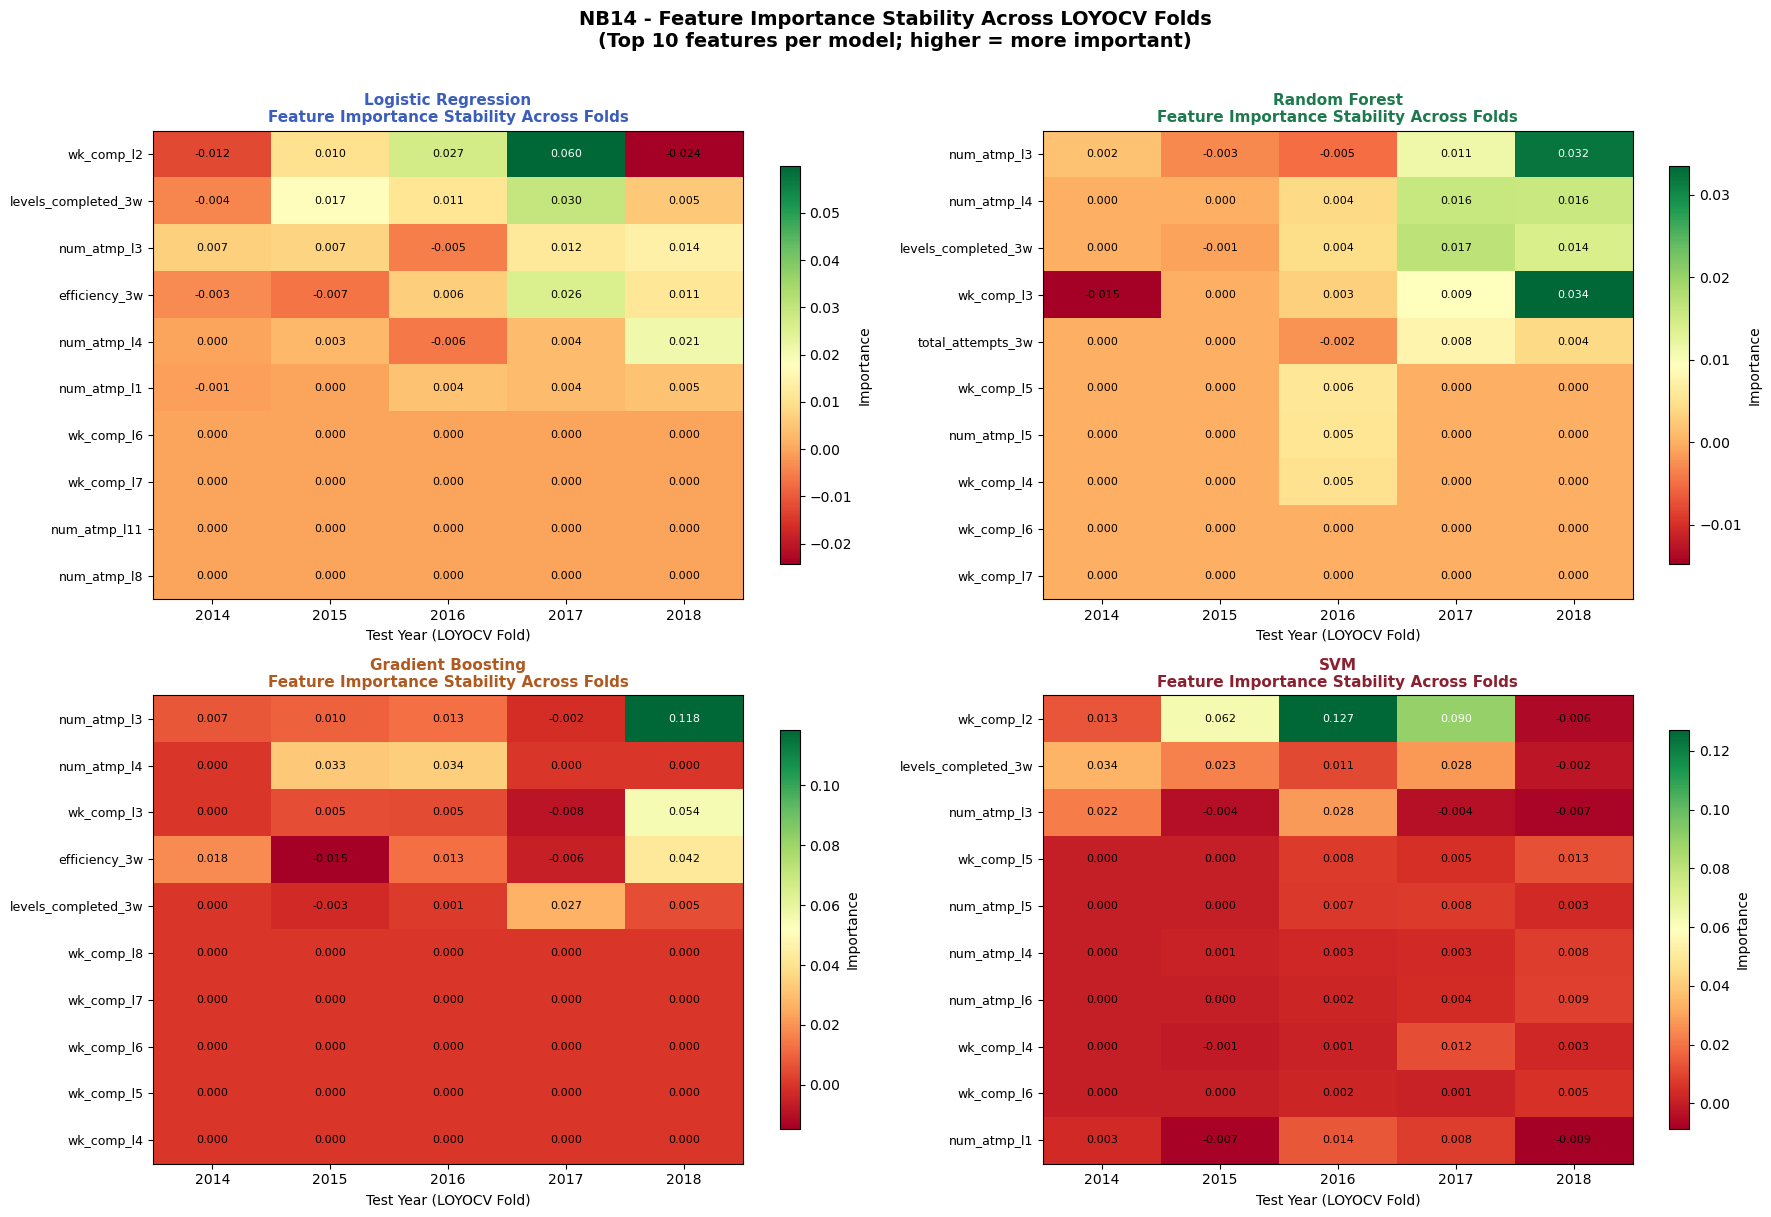

  ✓ Chart 2: Stability heatmap saved

All NB14 visualizations saved to Results4 folder.

NOTEBOOK 14_v2 COMPLETE


In [2]:
# NOTEBOOK 14_v2: FEATURE IMPORTANCE AND SELECTION (UPDATED)
# Permutation Importance + Stability Analysis + Reduced Feature Evaluation
# UPDATED: 5-fold LOYOCV, Balanced Accuracy-optimized thresholds

import os
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, recall_score,
    f1_score, roc_auc_score, make_scorer
)
from sklearn.inspection import permutation_importance
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows

def df_to_ws(ws, df, index=False, startrow=0):
    """Write a DataFrame to an openpyxl worksheet starting at startrow (0-indexed)."""
    for r_idx, row in enumerate(dataframe_to_rows(df, index=index, header=True),
                                start=startrow + 1):
        for c_idx, value in enumerate(row, start=1):
            ws.cell(row=r_idx, column=c_idx, value=value)
import warnings
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ═══════════════════════════════════════════════════════════════════════════════
RESULTS_DIR = os.path.join(os.getcwd(), "Results")
CHARTS_DIR  = os.path.join(os.getcwd(), "Charts")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHARTS_DIR,  exist_ok=True)

print("=" * 80)
print("NOTEBOOK 14_v2: FEATURE IMPORTANCE AND SELECTION (UPDATED)")
print("=" * 80)
print(f"Results directory: {RESULTS_DIR}")

# ═══════════════════════════════════════════════════════════════════════════════
# THRESHOLDS FROM NB13_v2 (Balanced Accuracy-optimized)
# ═══════════════════════════════════════════════════════════════════════════════
# TODO: Update these values after running NB13_v2
# These are PLACEHOLDERS - will be updated with actual NB13_v2 results
fixed_thresholds = {
    'Logistic Regression': 0.50,    'Random Forest': 0.55,          'Gradient Boosting': 0.60,      'SVM': 0.65                 }

print("\nTHRESHOLDS (from NB13_v2 Balanced Accuracy optimization):")
for model, thresh in fixed_thresholds.items():
    print(f"  {model:<25} {thresh:.2f}")

print("     Check: Notebook_13_v2_Results.xlsx 'threshold' column for per-year averages")

# Custom scorer for hyperparameter tuning
recall_fail_scorer = make_scorer(recall_score, pos_label=0)

# Hyperparameter grids (same as NB13_v2)
param_grids = {
    'Logistic Regression': {'C': [0.01, 0.1, 1.0, 10.0, 100.0]},
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, None],
        'min_samples_leaf': [1, 3, 5]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5],
        'subsample': [0.8, 1.0]
    },
    'SVM': {
        'C': [0.1, 1.0, 5.0, 10.0],
        'gamma': ['scale', 'auto']
    }
}

test_years = [2014, 2015, 2016, 2017, 2018]  # FIXED: Now includes 2014
model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM']
TOP_N = 10
N_REPEATS = 10

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1: LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════════
print("\nSTEP 1: Loading remediated features...")

try:
    modeling_data = pd.read_excel("modeling_dataset.xlsx")
    y = modeling_data["outcome"]
    year_col = modeling_data["year"].copy()
    
    X_remediated = pd.read_csv(os.path.join(RESULTS_DIR, "features_after_zero_ambiguity_fix.csv"))
    feature_cols_modeling = [
        c for c in X_remediated.columns
        if c not in ['last_completion_week', 'trailing_gap_weeks']
    ]
    X_model = X_remediated[feature_cols_modeling].copy()
    
    print(f"✓ Loaded {len(feature_cols_modeling)} features")
    print(f"✓ Outcome: Pass={sum(y==1)}, Fail={sum(y==0)}")
    print(f"✓ Test years: {test_years}")
    
except Exception as e:
    print(f"Error loading data: {e}")
    print("   Ensure modeling_dataset.xlsx and features_after_zero_ambiguity_fix.csv are present")

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2: LOYOCV WITH PERMUTATION IMPORTANCE
# ═══════════════════════════════════════════════════════════════════════════════
print(f"\nSTEP 2: LOYOCV evaluation ({len(test_years)}-fold, 2014-2018)...")

importances_by_model_year = {m: {} for m in model_names}
full_perf = {m: [] for m in model_names}

for test_year in test_years:
    print(f"\n  Test year: {int(test_year)}")
    
    train_mask = year_col != test_year
    test_mask = year_col == test_year
    
    X_train = X_model.loc[train_mask].copy()
    X_test = X_model.loc[test_mask].copy()
    y_train = y.loc[train_mask].copy()
    y_test = y.loc[test_mask].copy()
    
    for model_name in model_names:
        # Hyperparameter tuning on training set
        if model_name == 'Logistic Regression':
            scaler = StandardScaler()
            X_train_sc = scaler.fit_transform(X_train)
            X_test_sc = scaler.transform(X_test)
            
            grid = GridSearchCV(
                LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
                param_grids[model_name], cv=3, scoring=recall_fail_scorer, n_jobs=-1
            )
            grid.fit(X_train_sc, y_train)
            model = LogisticRegression(max_iter=1000, class_weight='balanced', 
                                      random_state=42, **grid.best_params_)
            model.fit(X_train_sc, y_train)
            y_prob = model.predict_proba(X_test_sc)[:, 1]
        # Permutation importance on test set
            pi = permutation_importance(model, X_test_sc, y_test,
                                    n_repeats=N_REPEATS, scoring='balanced_accuracy',
                                    random_state=42, n_jobs=-1)
            importances_by_model_year[model_name][test_year] = {'mean': pi.importances_mean, 'std': pi.importances_std}
            
        elif model_name == 'Random Forest':
            grid = GridSearchCV(
                RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
                param_grids[model_name], cv=3, scoring=recall_fail_scorer, n_jobs=-1
            )
            grid.fit(X_train, y_train)
            model = RandomForestClassifier(class_weight='balanced', random_state=42, 
                                          **grid.best_params_)
            model.fit(X_train, y_train)
            y_prob = model.predict_proba(X_test)[:, 1]
            pi = permutation_importance(model, X_test, y_test,
                                    n_repeats=N_REPEATS, scoring='balanced_accuracy',
                                    random_state=42, n_jobs=-1)
            importances_by_model_year[model_name][test_year] = {'mean': pi.importances_mean, 'std': pi.importances_std}
            
        elif model_name == 'Gradient Boosting':
            grid = GridSearchCV(
                GradientBoostingClassifier(random_state=42),
                param_grids[model_name], cv=3, scoring=recall_fail_scorer, n_jobs=-1
            )
            grid.fit(X_train, y_train)
            model = GradientBoostingClassifier(random_state=42, **grid.best_params_)
            model.fit(X_train, y_train)
            y_prob = model.predict_proba(X_test)[:, 1]
            pi = permutation_importance(model, X_test, y_test,
                                    n_repeats=N_REPEATS, scoring='balanced_accuracy',
                                    random_state=42, n_jobs=-1)
            importances_by_model_year[model_name][test_year] = {'mean': pi.importances_mean, 'std': pi.importances_std}
            
        elif model_name == 'SVM':
            scaler = StandardScaler()
            X_train_sc = scaler.fit_transform(X_train)
            X_test_sc = scaler.transform(X_test)
            
            grid = GridSearchCV(
                SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
                param_grids[model_name], cv=3, scoring=recall_fail_scorer, n_jobs=-1
            )
            grid.fit(X_train_sc, y_train)
            model = SVC(kernel='rbf', class_weight='balanced', probability=True, 
                       random_state=42, **grid.best_params_)
            model.fit(X_train_sc, y_train)
            y_prob = model.predict_proba(X_test_sc)[:, 1]
        pi = permutation_importance(model, X_test_sc, y_test,
                                    n_repeats=N_REPEATS, scoring='balanced_accuracy',
                                    random_state=42, n_jobs=-1)
        importances_by_model_year[model_name][test_year] = {'mean': pi.importances_mean, 'std': pi.importances_std}
        
        # Apply fixed threshold from NB13_v2
        thresh = fixed_thresholds[model_name]
        y_pred = (y_prob >= thresh).astype(int)
        
        # Store metrics
        full_perf[model_name].append({
            'test_year': int(test_year),
            'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
            'recall_fail': recall_score(y_test, y_pred, pos_label=0),
            'f1_fail': f1_score(y_test, y_pred, pos_label=0),
            'auc': roc_auc_score(y_test, y_prob)
        })

# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3: SUMMARY & EXPORT
# ═══════════════════════════════════════════════════════════════════════════════
print("\nSTEP 3: Generating summary...")

output_file = os.path.join(RESULTS_DIR, "Notebook_14_v2_Feature_Importance_Updated.xlsx")
wb = Workbook()
ws = wb.active
ws.title = "Full Feature Results"

# Write summary for each model
summary_rows = []
for model_name in model_names:
    df = pd.DataFrame(full_perf[model_name])
    summary_rows.append({
        'Model': model_name,
        'Bal.Acc (mean)': f"{df['balanced_accuracy'].mean():.3f}",
        'Bal.Acc (std)': f"{df['balanced_accuracy'].std():.3f}",
        'Recall(Fail)': f"{df['recall_fail'].mean():.3f}",
        'F1(Fail)': f"{df['f1_fail'].mean():.3f}",
        'AUC': f"{df['auc'].mean():.3f}"
    })

summary_df = pd.DataFrame(summary_rows)
df_to_ws(ws, summary_df, index=False, startrow=0)

# ── Autofit column widths ─────────────────────────────────────────────────────
for col_idx, col_name in enumerate(summary_df.columns, start=1):
    max_len = max(len(str(col_name)),
                  max((len(str(v)) for v in summary_df.iloc[:, col_idx-1]), default=0))
    from openpyxl.utils import get_column_letter
    ws.column_dimensions[get_column_letter(col_idx)].width = max_len + 4

# ── Bold header row ───────────────────────────────────────────────────────────
for cell in ws[1]:
    cell.font = Font(bold=True)


# Add per-model per-fold importance sheets
for model_name in model_names:
    ws_model = wb.create_sheet(f"{model_name} - Per Fold")
    # Build DataFrame: rows = features, cols = folds (mean importance)
    feature_names = list(X_model.columns)
    feature_cols  = feature_names 
    
    fold_data = {}
    for yr in test_years:
        fold_data[f"Year_{int(yr)}_Mean"] = importances_by_model_year[model_name][yr]['mean']
        fold_data[f"Year_{int(yr)}_Std"]  = importances_by_model_year[model_name][yr]['std']
    imp_df = pd.DataFrame(fold_data, index=feature_names)
    imp_df["Grand_Mean_Importance"] = np.array(
        [importances_by_model_year[model_name][yr]['mean'] for yr in test_years]
    ).mean(axis=0)
    imp_df["Grand_Std_Importance"] = np.array(
        [importances_by_model_year[model_name][yr]['std'] for yr in test_years]
    ).mean(axis=0)
    imp_df = imp_df.sort_values("Grand_Mean_Importance", ascending=False)
    imp_df.index.name = "Feature"
    df_to_ws(ws_model, imp_df, index=True, startrow=0)
    for col_idx in range(1, len(imp_df.columns) + 2):
        from openpyxl.utils import get_column_letter
        ws_model.column_dimensions[get_column_letter(col_idx)].width = 22

wb.save(output_file)
print(f"✓ Saved: {output_file}")

# ── Display in Jupyter ────────────────────────────────────────────────────────
print("\n" + "="*80)
print("SUMMARY TABLE (mean across LOYOCV folds)")
print("="*80)
try:
    from IPython.display import display as ipy_display
    ipy_display(summary_df)
except Exception:
    print(summary_df.to_string(index=False))


# ══════════════════════════════════════════════════════════════════════════════
# STEP 4: VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════
print("\nSTEP 4: Generating visualizations...")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

try:
    from IPython.display import display as ipy_display
except ImportError:
    ipy_display = lambda x: None

COLORS = {
    'Logistic Regression': '#3B5EBD',
    'Random Forest':       '#1E7A4E',
    'Gradient Boosting':   '#B05A20',
    'SVM':                 '#8B2030',
}

feature_names = list(X_model.columns)
feature_cols  = feature_names  # alias for chart labels

# ── CHART 1: Top-10 Features by Permutation Importance per model ─────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax_idx, model_name in enumerate(model_names):
    ax = axes[ax_idx]
    # Aggregate mean importance across all folds
    all_means = np.array([importances_by_model_year[model_name][yr]['mean']
                          for yr in test_years])
    all_stds  = np.array([importances_by_model_year[model_name][yr]['std']
                          for yr in test_years])
    mean_imp  = all_means.mean(axis=0)
    std_imp   = all_stds.mean(axis=0)

    # Sort by mean importance descending, pick top 10
    sorted_idx = np.argsort(mean_imp)[::-1][:TOP_N]
    top_names  = [feature_names[i] for i in sorted_idx]
    top_means  = mean_imp[sorted_idx]
    top_stds   = std_imp[sorted_idx]

    colors_bar = [COLORS[model_name] if v >= 0 else '#AAAAAA' for v in top_means]
    y_pos      = np.arange(TOP_N)[::-1]
    bars       = ax.barh(y_pos, top_means, xerr=top_stds, capsize=4,
                         color=colors_bar, alpha=0.85, edgecolor='white',
                         error_kw={'elinewidth': 1.2, 'ecolor': '#333333'})
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_names, fontsize=9)
    ax.set_xlabel('Mean Importance (Balanced Accuracy Drop)', fontsize=10)
    ax.set_title(f'{model_name}\nTop {TOP_N} Features (LOYOCV mean ±avg std)',
                 fontsize=11, fontweight='bold', color=COLORS[model_name])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.grid(axis='x', alpha=0.25, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('NB14 - Permutation Feature Importance by Model\n'
             '(Mean drop in Balanced Accuracy when feature is shuffled)',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, 'NB14_permutation_importance.png'), dpi=150, bbox_inches='tight')
ipy_display(fig)
plt.close(fig)
print("  ✓ Chart 1: Permutation importance saved")

# ── CHART 2: Feature Importance Stability heatmap (top 10 features × folds) ──
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax_idx, model_name in enumerate(model_names):
    ax = axes[ax_idx]
    # Identify top-10 features by mean across folds
    all_means = np.array([importances_by_model_year[model_name][yr]['mean']
                          for yr in test_years])
    grand_mean = all_means.mean(axis=0)
    top_idx    = np.argsort(grand_mean)[::-1][:TOP_N]
    top_names  = [feature_names[i] for i in top_idx]

    # Build heatmap: rows = features, cols = years
    heat = np.array([[importances_by_model_year[model_name][yr]['mean'][i]
                      for yr in test_years]
                     for i in top_idx])

    im = ax.imshow(heat, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(test_years)))
    ax.set_xticklabels([str(y) for y in test_years], fontsize=10)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_names, fontsize=9)
    ax.set_title(f'{model_name}\nFeature Importance Stability Across Folds',
                 fontsize=11, fontweight='bold', color=COLORS[model_name])
    ax.set_xlabel('Test Year (LOYOCV Fold)', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.85, label='Importance')

    for r in range(TOP_N):
        for c in range(len(test_years)):
            val   = heat[r, c]
            color = 'white' if val > heat.max() * 0.6 else 'black'
            ax.text(c, r, f'{val:.3f}', ha='center', va='center',
                    fontsize=8, color=color)

fig.suptitle('NB14 - Feature Importance Stability Across LOYOCV Folds\n'
             '(Top 10 features per model; higher = more important)',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, 'NB14_stability_heatmap.png'), dpi=150, bbox_inches='tight')
ipy_display(fig)
plt.close(fig)
print("  ✓ Chart 2: Stability heatmap saved")
print("\nAll NB14 visualizations saved to Results4 folder.")

print("\n" + "="*80)
print("NOTEBOOK 14_v2 COMPLETE")
print("="*80)



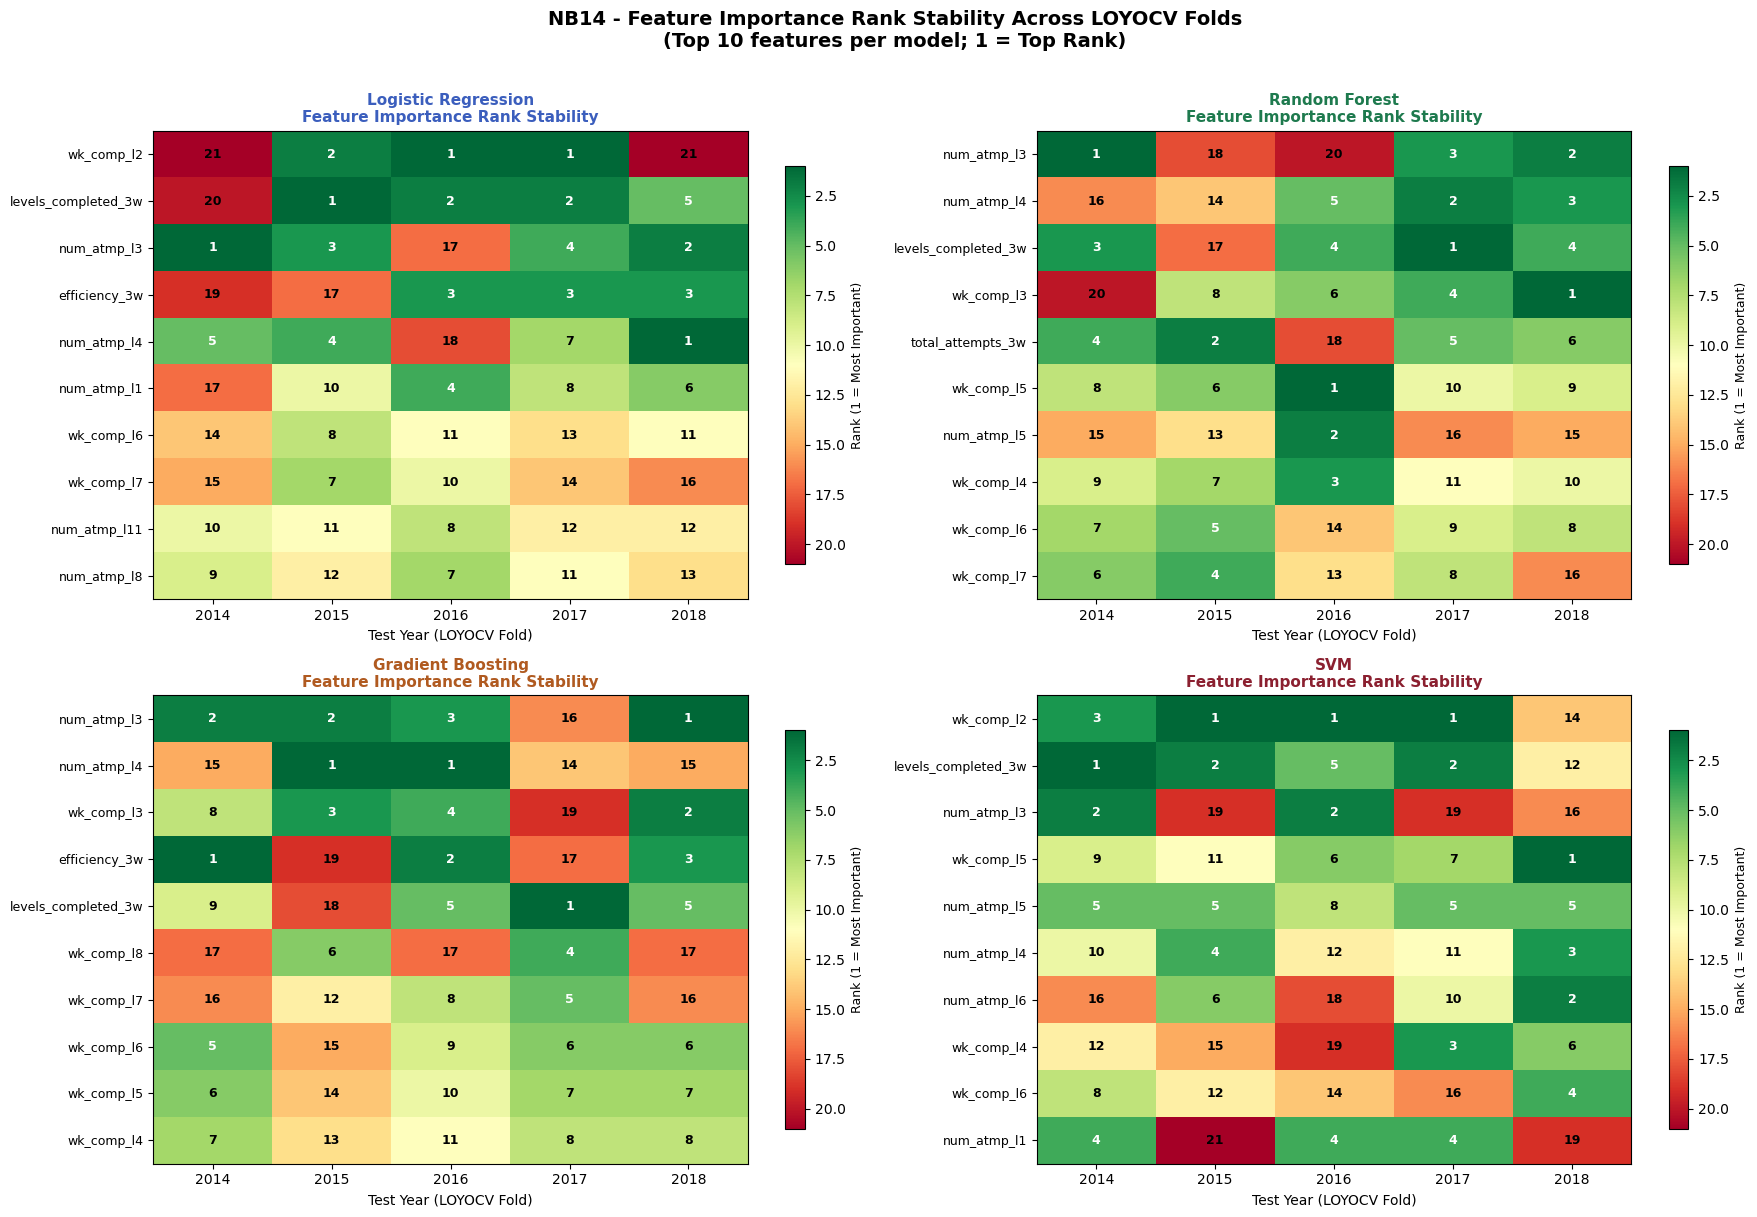

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ── CHART 3: Feature Importance Rank Stability Heatmap ──
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for ax_idx, model_name in enumerate(model_names):
    ax = axes[ax_idx]
    
    # 1. Identify top-10 features by grand mean (to keep row order consistent)
    all_means = np.array([importances_by_model_year[model_name][yr]['mean']
                          for yr in test_years])
    grand_mean = all_means.mean(axis=0)
    top_idx    = np.argsort(grand_mean)[::-1][:TOP_N]
    top_names  = [feature_names[i] for i in top_idx]
    
    # 2. Build Rank Heatmap: 
    # We calculate the rank for EVERY feature in a year, then extract our top 10
    rank_matrix = []
    for yr in test_years:
        year_importances = importances_by_model_year[model_name][yr]['mean']
        # Rank: 1 = highest importance, 21 = lowest
        # argsort once gives indices, argsort again gives the rank positions
        ranks = np.empty_like(year_importances, dtype=int)
        ranks[np.argsort(-year_importances)] = np.arange(1, len(year_importances) + 1)
        rank_matrix.append(ranks[top_idx])
    
    # Transpose so rows = features, cols = years
    heat_rank = np.array(rank_matrix).T 
    
    # 3. Plotting (using 'RdYlGn_r' so Rank 1 is dark green)
    im = ax.imshow(heat_rank, cmap='RdYlGn_r', aspect='auto', vmin=1, vmax=len(feature_names))
    
    ax.set_xticks(range(len(test_years)))
    ax.set_xticklabels([str(y) for y in test_years], fontsize=10)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top_names, fontsize=9)
    
    ax.set_title(f'{model_name}\nFeature Importance Rank Stability',
                 fontsize=11, fontweight='bold', color=COLORS[model_name])
    ax.set_xlabel('Test Year (LOYOCV Fold)', fontsize=10)
    
    # Colorbar adjustment
    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label('Rank (1 = Most Important)', fontsize=9)
    cbar.ax.invert_yaxis() # Invert colorbar so 1 is at the top
    
    # 4. Add Text Labels (Ranks as Integers)
    for r in range(TOP_N):
        for c in range(len(test_years)):
            val = heat_rank[r, c]
            # Text color logic: White for very high ranks (low numbers), black for others
            text_color = 'white' if val <= 5 else 'black'
            ax.text(c, r, f'{int(val)}', ha='center', va='center',
                    fontsize=9, fontweight='bold', color=text_color)

fig.suptitle('NB14 - Feature Importance Rank Stability Across LOYOCV Folds\n'
             '(Top 10 features per model; 1 = Top Rank)',
             fontsize=14, fontweight='bold', y=1.01)

fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, 'NB14_rank_stability_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# References

- Scikit-learn Documentation: https://scikit-learn.org/stable/
- Grid Search: https://scikit-learn.org/stable/modules/grid_search.html
- Balanced Accuracy: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html
- Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Random Forest: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- SVM: https://scikit-learn.org/stable/modules/svm.html
- Permutation Importance: https://scikit-learn.org/stable/modules/permutation_importance.html
- Permutation Importance (guide): https://www.geeksforgeeks.org/permutation-importance-in-machine-learning/